# Importing data

In [1]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd /home/565/pv3484/aus_substation_electricity

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

## Holiday function

In [3]:
import pandas as pd
from datetime import date, timedelta
from dateutil.easter import easter

#Monarch's Birthday
def second_monday_of_june(y):
    """Return the date of the second Monday in June for year y."""
    june = pd.date_range(start=f"{y}-06-01", end=f"{y}-06-30", freq="D")
    mondays = june[june.weekday == 0]   # Monday = 0
    return mondays[1]                   # second Monday



# Define all national public holidays (including moving ones like Easter)
HOLIDAYS_VIC = {
    "New Year's Day": lambda y: pd.Timestamp(f"{y}-01-01"),
    "Australia Day": lambda y: pd.Timestamp(f"{y}-01-26"),
    "Good Friday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=2),
    "Easter Saturday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=1),
    "Easter Sunday": lambda y: pd.Timestamp(easter(y)),
    "Easter Monday": lambda y: pd.Timestamp(easter(y)) + pd.Timedelta(days=1),
    "ANZAC Day": lambda y: pd.Timestamp(f"{y}-04-25"),
    "Queen's Birthday": lambda y: second_monday_of_june(y),
    "Christmas Day": lambda y: pd.Timestamp(f"{y}-12-25"),
    "Boxing Day": lambda y: pd.Timestamp(f"{y}-12-26"),
}

holiday_order = list(HOLIDAYS_VIC.keys())

## Importing csv files

In [4]:
import pandas as pd

demand_rank = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv")

weather_rank = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/weather_holiday_block_means_with_codes.csv")

In [5]:
#replacing Monarch's Birthday with Queen's Birthday (same day, not change in data, just title change)

demand_rank["holiday_group"] = demand_rank["holiday_group"].replace({
    "Monarch's Birthday": "Queen's Birthday"
})

weather_rank["holiday_group"] = weather_rank["holiday_group"].replace({
    "Monarch's Birthday": "Queen's Birthday"
})


# Plotting temperature v relative humidity
- colour of dot = rh
- x = temp
- y = mrr

In [17]:
def plot_humidity_scatter_for_station(
    demand_rank,
    weather_rank,
    station_code,
    holiday_name,
    time_blocks=None
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    if time_blocks is None:
        time_blocks = ["00_04", "04_10", "10_15", "15_20", "20_24"]

    block_titles = ["12am–4am", "4am–10am", "10am–3pm", "3pm–8pm", "8pm–12am"]

    # --- Filter demand and weather ---
    df_d = demand_rank[
        (demand_rank["station_code"] == station_code) &
        (demand_rank["holiday_group"] == holiday_name)
    ].copy()
    if df_d.empty:
        return None, ["NO DEMAND DATA"]

    df_w = weather_rank[
        (weather_rank["holiday_group"] == holiday_name) &
        (weather_rank["station_code"] == station_code)
    ].copy()
    if df_w.empty:
        return None, ["NO WEATHER DATA"]

    # --- Merge ---
    merged = pd.merge(
        df_d, df_w,
        on=["date", "holiday_group", "station_code"],
        how="inner",
        suffixes=("", "_w")
    )
    if merged.empty:
        return None, ["NO MERGED DATA"]

    merged["is_weekend"] = merged.get("is_weekend", merged.get("is_weekend_w"))
    merged["is_holiday"] = merged.get("is_holiday", merged.get("is_holiday_w"))

    full_station_name = merged["Name"].iloc[0] if "Name" in merged.columns else station_code

    # --- Global humidity range across all blocks (holiday rows only) ---
    holiday_rows_all = merged[merged["is_holiday"]]
    hum_cols = [
        f"{block}_relative_humidity"
        for block in time_blocks
        if f"{block}_relative_humidity" in merged.columns
    ]

    if hum_cols and not holiday_rows_all[hum_cols].isna().all().all():
        global_hum_min = holiday_rows_all[hum_cols].min().min()
        global_hum_max = holiday_rows_all[hum_cols].max().max()
        if global_hum_min == global_hum_max:
            global_hum_min -= 0.5
            global_hum_max += 0.5
    else:
        global_hum_min, global_hum_max = 0, 100

    hum_norm = Normalize(vmin=global_hum_min, vmax=global_hum_max)
    hum_cmap = plt.cm.Spectral_r

    weekday_color = "#D8D8D8"
    weekend_color = "skyblue"

    # --- Plot ---
    fig, axes = plt.subplots(
        1, len(time_blocks),
        figsize=(4.5 * len(time_blocks), 5.0),
        sharey=False
    )

    for col_idx, block in enumerate(time_blocks):
        ax        = axes[col_idx]
        rank_col  = f"{block}_mean_relative_rank"
        x_col     = f"{block}_temp"
        hum_col   = f"{block}_relative_humidity"

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in merged.columns or x_col not in merged.columns or merged[x_col].isna().all():
            ax.set_visible(False)
            continue

        # Weekday background
        wd = merged[~merged["is_weekend"]]
        ax.scatter(wd[x_col], wd[rank_col],
                   color=weekday_color, alpha=0.35, s=35, zorder=1)

        # Weekend background
        we = merged[merged["is_weekend"]]
        ax.scatter(we[x_col], we[rank_col],
                   color=weekend_color, alpha=0.45, s=35, zorder=1)

        # Holiday dots coloured by relative humidity
        holiday_rows = merged[merged["is_holiday"]].copy()

        if hum_col in merged.columns and not holiday_rows[hum_col].isna().all():
            colors = hum_cmap(hum_norm(holiday_rows[hum_col].values))
        else:
            colors = ["#AAAAAA"] * len(holiday_rows)

        ax.scatter(
            holiday_rows[x_col], holiday_rows[rank_col],
            c=colors, s=120, edgecolor="black", linewidth=0.7, zorder=2
        )

        ax.set_xlabel("Temperature (°C)", fontsize=13)
        if col_idx == 0:
            ax.set_ylabel("Mean Relative Rank", fontsize=13)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    # --- Title ---
    fig.suptitle(
        f"{holiday_name} — {full_station_name}\n"
        f"Temperature vs Mean Relative Rank  |  Holiday coloured by Relative Humidity",
        fontsize=16, y=1.05, linespacing=1.3
    )

    # --- Day type legend ---
    weekday_handle = plt.Line2D([], [], marker="o", linestyle="",
                                color=weekday_color, markersize=8, label="Weekday")
    weekend_handle = plt.Line2D([], [], marker="o", linestyle="",
                                color=weekend_color, markersize=8, label="Weekend")
    fig.legend(
        handles=[weekday_handle, weekend_handle],
        title="Day Type", title_fontsize=12, fontsize=12,
        loc="center", bbox_to_anchor=(0.3, 0.04),
        borderpad=0.4, labelspacing=0.3, handletextpad=0.4,
        ncol=1, frameon=True
    )

    # --- Colorbar ---
    sm = ScalarMappable(cmap=hum_cmap, norm=Normalize(vmin=0, vmax=100))
    sm.set_array([])
    cbar_ax = fig.add_axes([0.35, 0.055, 0.28, 0.03])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_ticks(range(0, 101, 20))
    cbar.set_ticklabels([f"{t}%" for t in range(0, 101, 20)])
    cbar.set_label("Relative Humidity (%)", fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    fig.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.98, wspace=0.18)

    return fig, []

(<Figure size 2250x500 with 6 Axes>, [])

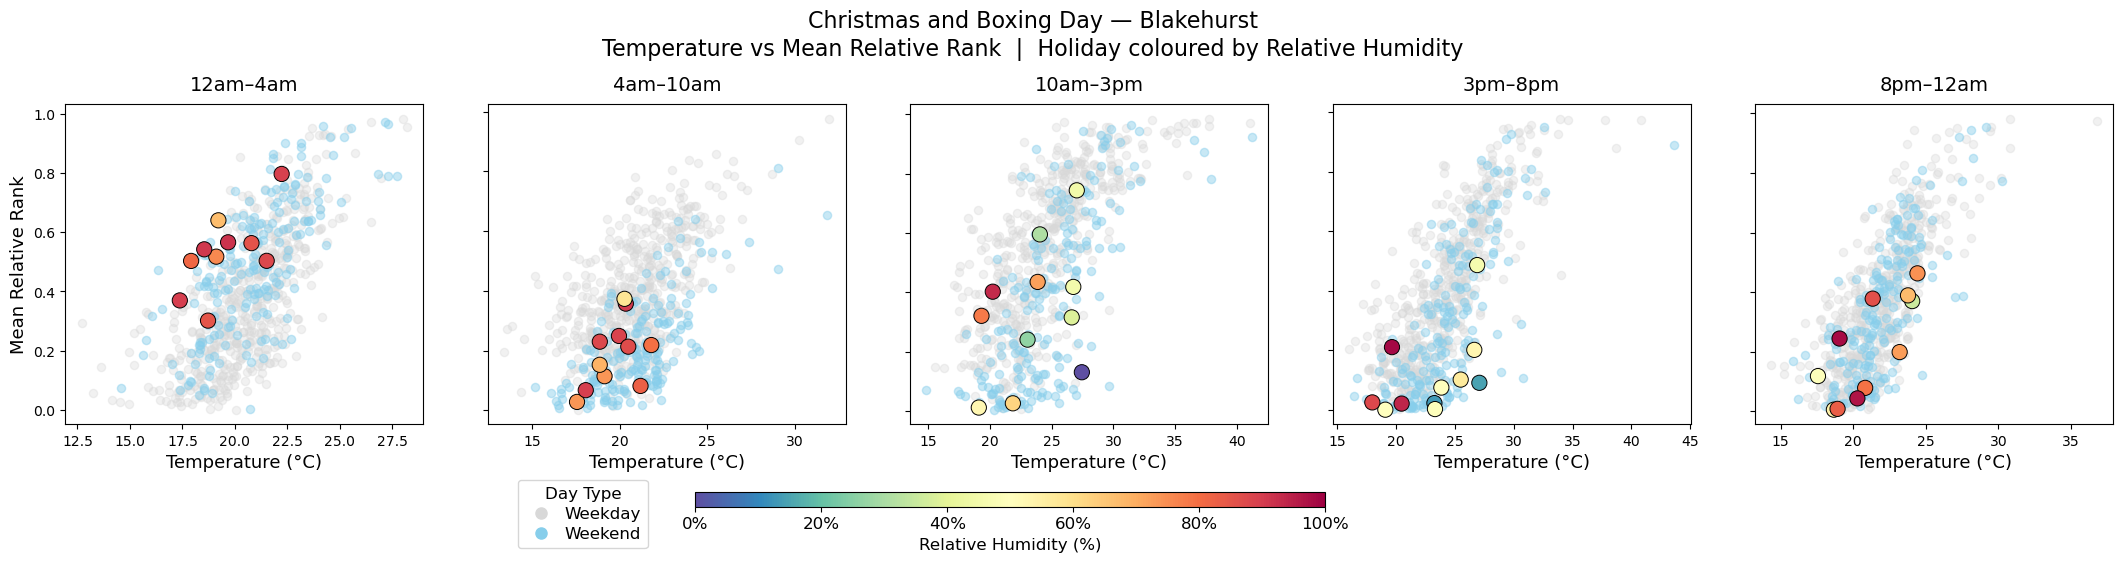

In [19]:
plot_humidity_scatter_for_station(
    demand_rank,
    weather_rank,
    "BLAKE",
    "Christmas and Boxing Day"
)

# Adding statistical testing

In [20]:
def plot_humidity_scatter_with_stats(
    demand_rank,
    weather_rank,
    station_code,
    holiday_name,
    time_blocks=None
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    from scipy import stats

    if time_blocks is None:
        time_blocks = ["00_04", "04_10", "10_15", "15_20", "20_24"]

    block_titles = ["12am–4am", "4am–10am", "10am–3pm", "3pm–8pm", "8pm–12am"]

    # --- Filter demand and weather ---
    df_d = demand_rank[
        (demand_rank["station_code"] == station_code) &
        (demand_rank["holiday_group"] == holiday_name)
    ].copy()
    if df_d.empty:
        return None, ["NO DEMAND DATA"]

    df_w = weather_rank[
        (weather_rank["holiday_group"] == holiday_name) &
        (weather_rank["station_code"] == station_code)
    ].copy()
    if df_w.empty:
        return None, ["NO WEATHER DATA"]

    # --- Merge ---
    merged = pd.merge(
        df_d, df_w,
        on=["date", "holiday_group", "station_code"],
        how="inner",
        suffixes=("", "_w")
    )
    if merged.empty:
        return None, ["NO MERGED DATA"]

    merged["is_weekend"] = merged.get("is_weekend", merged.get("is_weekend_w"))
    merged["is_holiday"] = merged.get("is_holiday", merged.get("is_holiday_w"))

    full_station_name = merged["Name"].iloc[0] if "Name" in merged.columns else station_code

    # --- Global humidity range across all blocks (holiday rows only) ---
    holiday_rows_all = merged[merged["is_holiday"]]
    hum_cols = [
        f"{block}_relative_humidity"
        for block in time_blocks
        if f"{block}_relative_humidity" in merged.columns
    ]

    if hum_cols and not holiday_rows_all[hum_cols].isna().all().all():
        global_hum_min = holiday_rows_all[hum_cols].min().min()
        global_hum_max = holiday_rows_all[hum_cols].max().max()
        if global_hum_min == global_hum_max:
            global_hum_min -= 0.5
            global_hum_max += 0.5
    else:
        global_hum_min, global_hum_max = 0, 100

    hum_norm = Normalize(vmin=global_hum_min, vmax=global_hum_max)
    hum_cmap = plt.cm.Spectral_r

    weekday_color = "#D8D8D8"
    weekend_color = "skyblue"

    # --- Plot ---
    fig, axes = plt.subplots(
        1, len(time_blocks),
        figsize=(4.5 * len(time_blocks), 5.5),
        sharey=False
    )

    for col_idx, block in enumerate(time_blocks):
        ax       = axes[col_idx]
        rank_col = f"{block}_mean_relative_rank"
        x_col    = f"{block}_temp"
        hum_col  = f"{block}_relative_humidity"

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in merged.columns or x_col not in merged.columns or merged[x_col].isna().all():
            ax.set_visible(False)
            continue

        # Weekday background
        wd = merged[~merged["is_weekend"]]
        ax.scatter(wd[x_col], wd[rank_col],
                   color=weekday_color, alpha=0.35, s=35, zorder=1)

        # Weekend background
        we = merged[merged["is_weekend"]]
        ax.scatter(we[x_col], we[rank_col],
                   color=weekend_color, alpha=0.45, s=35, zorder=1)

        # Holiday dots coloured by relative humidity
        holiday_rows = merged[merged["is_holiday"]].copy()

        if hum_col in merged.columns and not holiday_rows[hum_col].isna().all():
            colors = hum_cmap(hum_norm(holiday_rows[hum_col].values))
        else:
            colors = ["#AAAAAA"] * len(holiday_rows)

        ax.scatter(
            holiday_rows[x_col], holiday_rows[rank_col],
            c=colors, s=120, edgecolor="black", linewidth=0.7, zorder=2
        )

        # --- Spearman correlations (holiday points only) ---
        stat_lines = []

        temp_vals = holiday_rows[x_col].dropna()
        rank_vals = holiday_rows[rank_col].reindex(temp_vals.index).dropna()
        temp_vals = temp_vals.reindex(rank_vals.index)

        if len(temp_vals) >= 4:
            rho_t, p_t = stats.spearmanr(temp_vals, rank_vals)
            sig_t = "**" if p_t < 0.01 else "*" if p_t < 0.05 else ""
            stat_lines.append(f"Temp:  ρ={rho_t:+.2f}, p={p_t:.2f}{sig_t}")
        else:
            stat_lines.append("Temp:  insufficient data")

        if hum_col in merged.columns:
            hum_vals  = holiday_rows[hum_col].dropna()
            rank_hum  = holiday_rows[rank_col].reindex(hum_vals.index).dropna()
            hum_vals  = hum_vals.reindex(rank_hum.index)

            if len(hum_vals) >= 4:
                rho_h, p_h = stats.spearmanr(hum_vals, rank_hum)
                sig_h = "**" if p_h < 0.01 else "*" if p_h < 0.05 else ""
                stat_lines.append(f"Humid: ρ={rho_h:+.2f}, p={p_h:.2f}{sig_h}")
            else:
                stat_lines.append("Humid: insufficient data")

        # Annotate stats in bottom-right corner
        ax.annotate(
            "\n".join(stat_lines),
            xy=(0.97, 0.04),
            xycoords="axes fraction",
            ha="right", va="bottom",
            fontsize=8.5,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="lightgray")
        )

        ax.set_xlabel("Temperature (°C)", fontsize=13)
        if col_idx == 0:
            ax.set_ylabel("Mean Relative Rank", fontsize=13)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    # --- Title ---
    fig.suptitle(
        f"{holiday_name} — {full_station_name}\n"
        f"Temperature vs Mean Relative Rank  |  Holiday coloured by Relative Humidity",
        fontsize=16, y=1.05, linespacing=1.3
    )

    # --- Day type legend ---
    weekday_handle = plt.Line2D([], [], marker="o", linestyle="",
                                color=weekday_color, markersize=8, label="Weekday")
    weekend_handle = plt.Line2D([], [], marker="o", linestyle="",
                                color=weekend_color, markersize=8, label="Weekend")
    fig.legend(
        handles=[weekday_handle, weekend_handle],
        title="Day Type", title_fontsize=12, fontsize=12,
        loc="center", bbox_to_anchor=(0.3, 0.04),
        borderpad=0.4, labelspacing=0.3, handletextpad=0.4,
        ncol=1, frameon=True
    )

    # --- Colorbar ---
    sm = ScalarMappable(cmap=hum_cmap, norm=Normalize(vmin=0, vmax=100))
    sm.set_array([])
    cbar_ax = fig.add_axes([0.35, 0.055, 0.28, 0.03])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_ticks(range(0, 101, 20))
    cbar.set_ticklabels([f"{t}%" for t in range(0, 101, 20)])
    cbar.set_label("Relative Humidity (%)", fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    fig.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.98, wspace=0.18)

    return fig, []

(<Figure size 2250x550 with 6 Axes>, [])

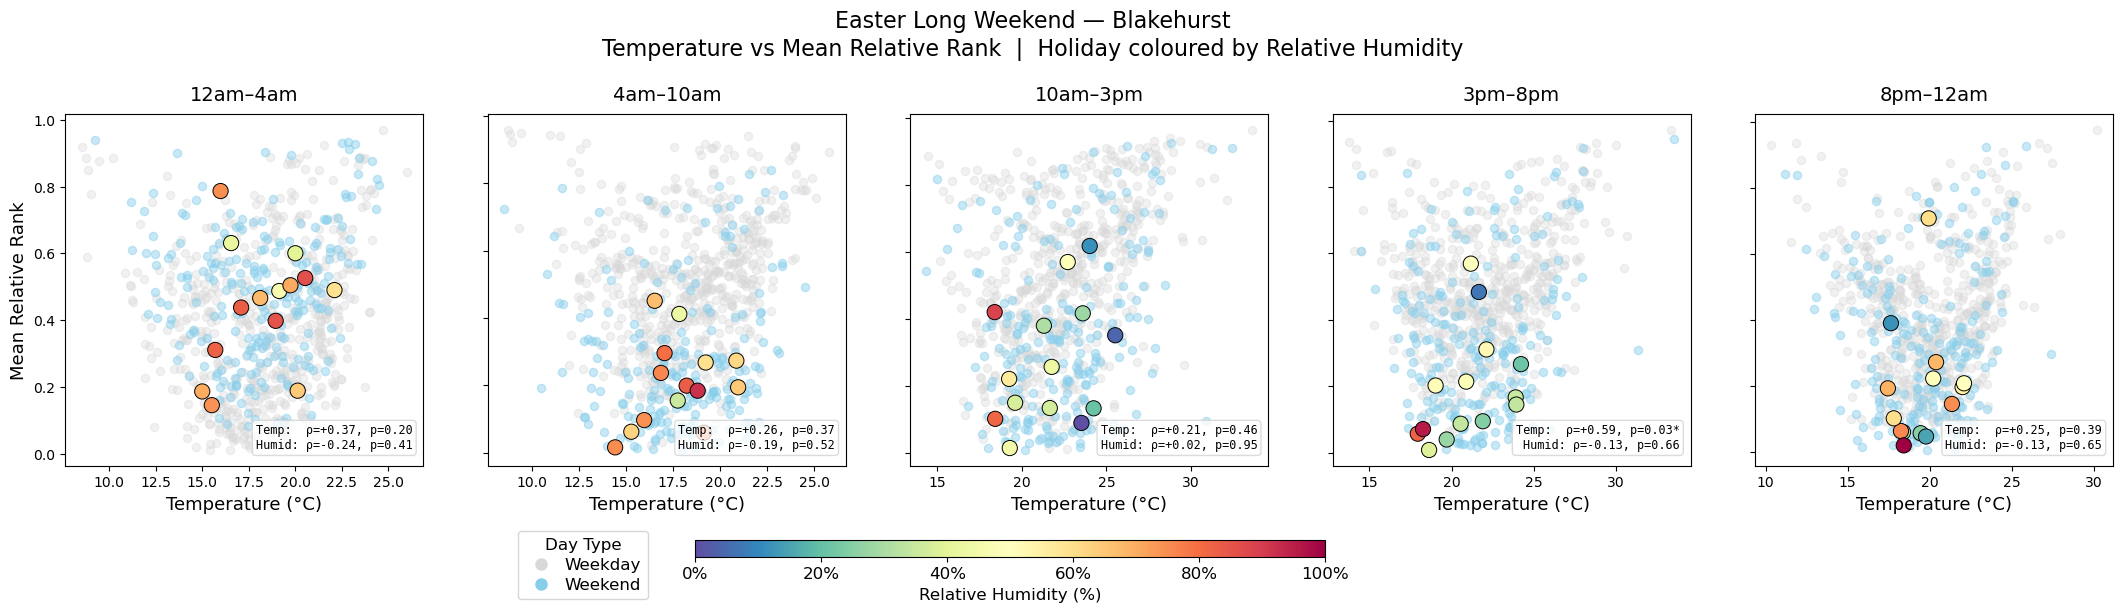

In [26]:
plot_humidity_scatter_with_stats(
    demand_rank,
    weather_rank,
    "BLAKE",
    "Easter Long Weekend"
)

In [27]:
print([c for c in weather_rank.columns if any(x in c.lower() for x in ["rain", "precip", "wind"])])

['00_04_wind_speed_kmh', '04_10_wind_speed_kmh', '10_15_wind_speed_kmh', '15_20_wind_speed_kmh', '20_24_wind_speed_kmh', '00_04_precip_incremental', '04_10_precip_incremental', '10_15_precip_incremental', '15_20_precip_incremental', '20_24_precip_incremental']


# Replacing relative humidity with wind speed

In [28]:
wind_cols = [c for c in weather_rank.columns if "wind_speed" in c]
print(weather_rank[wind_cols].describe())

       00_04_wind_speed_kmh  04_10_wind_speed_kmh  10_15_wind_speed_kmh  15_20_wind_speed_kmh  20_24_wind_speed_kmh
count         480052.000000         480307.000000         480919.000000         480670.000000         480302.000000
mean              10.952650             11.548190             17.536349             18.515879             13.146997
std                8.883046              8.339693              8.430761              9.145310              9.162059
min                0.000000              0.000000              0.000000              0.000000              0.000000
25%                4.150000              5.300000             11.370000             11.920000              6.775000
50%                9.850000             10.218182             15.925000             17.590000             11.875000
75%               15.175000             15.450000             22.210000             23.910000             17.837500
max               87.475000             91.883333             85.090000 

In [29]:
def plot_windspeed_scatter_for_station(
    demand_rank,
    weather_rank,
    station_code,
    holiday_name,
    time_blocks=None
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    from scipy import stats

    if time_blocks is None:
        time_blocks = ["00_04", "04_10", "10_15", "15_20", "20_24"]

    block_titles = ["12am–4am", "4am–10am", "10am–3pm", "3pm–8pm", "8pm–12am"]

    # --- Filter demand and weather ---
    df_d = demand_rank[
        (demand_rank["station_code"] == station_code) &
        (demand_rank["holiday_group"] == holiday_name)
    ].copy()
    if df_d.empty:
        return None, ["NO DEMAND DATA"]

    df_w = weather_rank[
        (weather_rank["holiday_group"] == holiday_name) &
        (weather_rank["station_code"] == station_code)
    ].copy()
    if df_w.empty:
        return None, ["NO WEATHER DATA"]

    # --- Merge ---
    merged = pd.merge(
        df_d, df_w,
        on=["date", "holiday_group", "station_code"],
        how="inner",
        suffixes=("", "_w")
    )
    if merged.empty:
        return None, ["NO MERGED DATA"]

    merged["is_weekend"] = merged.get("is_weekend", merged.get("is_weekend_w"))
    merged["is_holiday"] = merged.get("is_holiday", merged.get("is_holiday_w"))

    full_station_name = merged["Name"].iloc[0] if "Name" in merged.columns else station_code

    # --- Global wind speed range across all blocks (holiday rows only) ---
    holiday_rows_all = merged[merged["is_holiday"]]
    wind_cols = [
        f"{block}_wind_speed_kmh"
        for block in time_blocks
        if f"{block}_wind_speed_kmh" in merged.columns
    ]

    if wind_cols and not holiday_rows_all[wind_cols].isna().all().all():
        global_wind_min = holiday_rows_all[wind_cols].min().min()
        global_wind_max = holiday_rows_all[wind_cols].max().max()
        if global_wind_min == global_wind_max:
            global_wind_min -= 0.5
            global_wind_max += 0.5
    else:
        global_wind_min, global_wind_max = 0, 60

    wind_norm = Normalize(vmin=global_wind_min, vmax=global_wind_max)
    wind_cmap = plt.cm.YlGnBu  # light = calm, dark = windy

    weekday_color = "#D8D8D8"
    weekend_color = "skyblue"

    # --- Plot ---
    fig, axes = plt.subplots(
        1, len(time_blocks),
        figsize=(4.5 * len(time_blocks), 5.5),
        sharey=False
    )

    for col_idx, block in enumerate(time_blocks):
        ax        = axes[col_idx]
        rank_col  = f"{block}_mean_relative_rank"
        x_col     = f"{block}_temp"
        wind_col  = f"{block}_wind_speed_kmh"

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in merged.columns or x_col not in merged.columns or merged[x_col].isna().all():
            ax.set_visible(False)
            continue

        # Weekday background
        wd = merged[~merged["is_weekend"]]
        ax.scatter(wd[x_col], wd[rank_col],
                   color=weekday_color, alpha=0.35, s=35, zorder=1)

        # Weekend background
        we = merged[merged["is_weekend"]]
        ax.scatter(we[x_col], we[rank_col],
                   color=weekend_color, alpha=0.45, s=35, zorder=1)

        # Holiday dots coloured by wind speed
        holiday_rows = merged[merged["is_holiday"]].copy()

        if wind_col in merged.columns and not holiday_rows[wind_col].isna().all():
            colors = wind_cmap(wind_norm(holiday_rows[wind_col].values))
        else:
            colors = ["#AAAAAA"] * len(holiday_rows)

        ax.scatter(
            holiday_rows[x_col], holiday_rows[rank_col],
            c=colors, s=120, edgecolor="black", linewidth=0.7, zorder=2
        )

        # --- Spearman correlations (holiday points only) ---
        stat_lines = []

        temp_vals = holiday_rows[x_col].dropna()
        rank_vals = holiday_rows[rank_col].reindex(temp_vals.index).dropna()
        temp_vals = temp_vals.reindex(rank_vals.index)

        if len(temp_vals) >= 4:
            rho_t, p_t = stats.spearmanr(temp_vals, rank_vals)
            sig_t = "**" if p_t < 0.01 else "*" if p_t < 0.05 else ""
            stat_lines.append(f"Temp:  ρ={rho_t:+.2f}, p={p_t:.2f}{sig_t}")
        else:
            stat_lines.append("Temp:  insufficient data")

        if wind_col in merged.columns:
            wind_vals = holiday_rows[wind_col].dropna()
            rank_wind = holiday_rows[rank_col].reindex(wind_vals.index).dropna()
            wind_vals = wind_vals.reindex(rank_wind.index)

            if len(wind_vals) >= 4:
                rho_w, p_w = stats.spearmanr(wind_vals, rank_wind)
                sig_w = "**" if p_w < 0.01 else "*" if p_w < 0.05 else ""
                stat_lines.append(f"Wind:  ρ={rho_w:+.2f}, p={p_w:.2f}{sig_w}")
            else:
                stat_lines.append("Wind:  insufficient data")

        ax.annotate(
            "\n".join(stat_lines),
            xy=(0.97, 0.04),
            xycoords="axes fraction",
            ha="right", va="bottom",
            fontsize=8.5,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="lightgray")
        )

        ax.set_xlabel("Temperature (°C)", fontsize=13)
        if col_idx == 0:
            ax.set_ylabel("Mean Relative Rank", fontsize=13)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    # --- Title ---
    fig.suptitle(
        f"{holiday_name} — {full_station_name}\n"
        f"Temperature vs Mean Relative Rank  |  Holiday coloured by Wind Speed",
        fontsize=16, y=1.05, linespacing=1.3
    )

    # --- Day type legend ---
    weekday_handle = plt.Line2D([], [], marker="o", linestyle="",
                                color=weekday_color, markersize=8, label="Weekday")
    weekend_handle = plt.Line2D([], [], marker="o", linestyle="",
                                color=weekend_color, markersize=8, label="Weekend")
    fig.legend(
        handles=[weekday_handle, weekend_handle],
        title="Day Type", title_fontsize=12, fontsize=12,
        loc="center", bbox_to_anchor=(0.3, 0.04),
        borderpad=0.4, labelspacing=0.3, handletextpad=0.4,
        ncol=1, frameon=True
    )

    # --- Colorbar ---
    sm = ScalarMappable(cmap=wind_cmap, norm=Normalize(vmin=global_wind_min, vmax=global_wind_max))
    sm.set_array([])
    cbar_ax = fig.add_axes([0.35, 0.055, 0.28, 0.03])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Wind Speed (km/h)", fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    fig.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.98, wspace=0.18)

    return fig, []

(<Figure size 2250x550 with 6 Axes>, [])

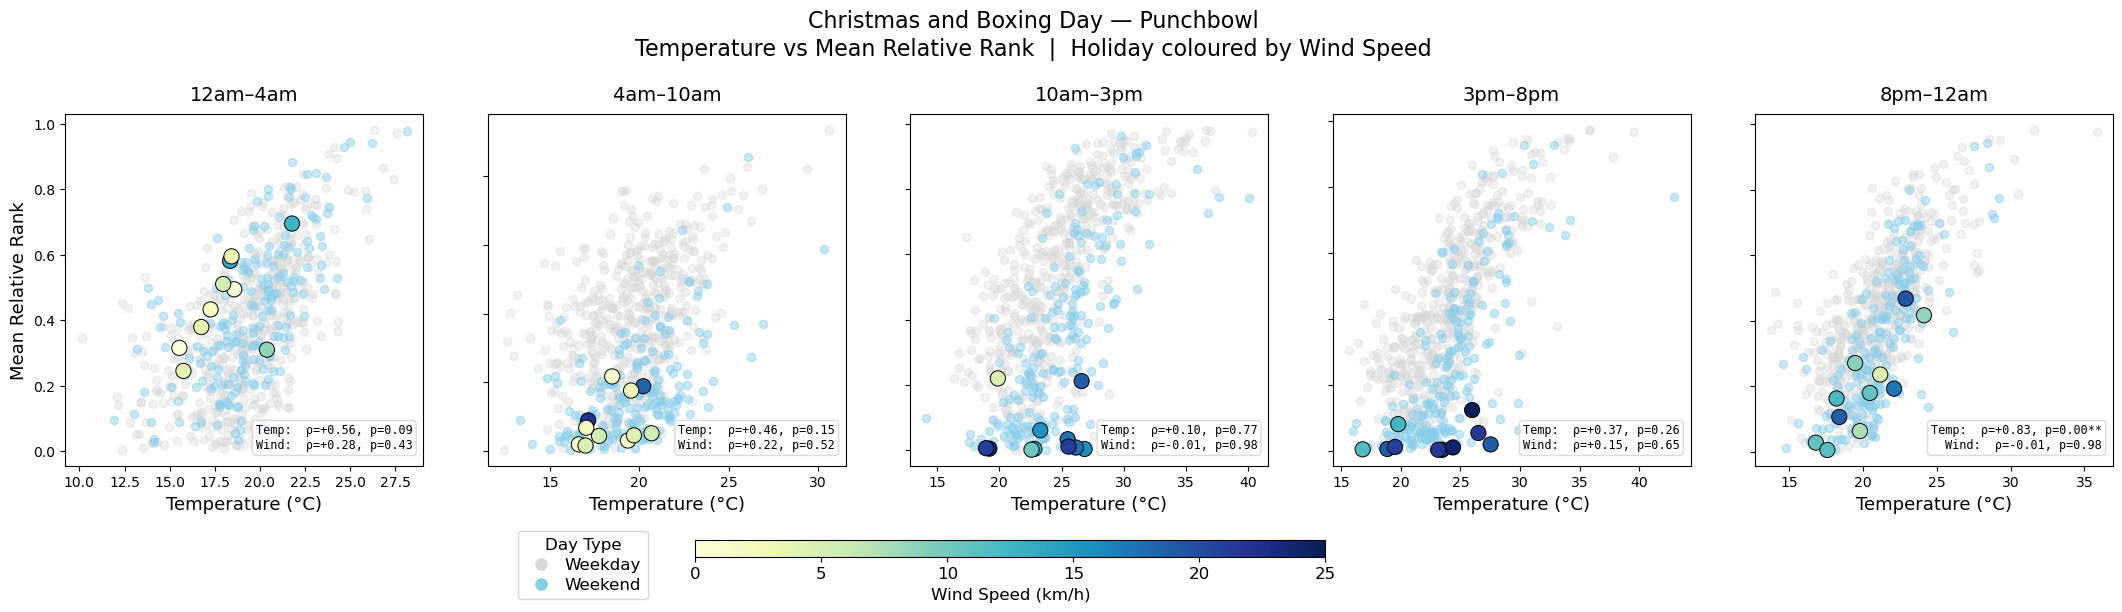

In [36]:
plot_windspeed_scatter_for_station(
    demand_rank,
    weather_rank,
    "PUNCH",
    "Christmas and Boxing Day"
)

# Mann-Whitney pvalue comparing weekends and weekdays to the public holiday
- produce strip and box plots

In [37]:
def plot_rank_boxstrip_by_daytype(
    demand_rank,
    weather_rank,
    station_code,
    holiday_name,
    time_blocks=None
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy import stats

    if time_blocks is None:
        time_blocks = ["00_04", "04_10", "10_15", "15_20", "20_24"]

    block_titles = ["12am–4am", "4am–10am", "10am–3pm", "3pm–8pm", "8pm–12am"]

    # --- Filter ---
    df_d = demand_rank[
        (demand_rank["station_code"] == station_code) &
        (demand_rank["holiday_group"] == holiday_name)
    ].copy()
    if df_d.empty:
        return None, ["NO DEMAND DATA"]

    df_w = weather_rank[
        (weather_rank["holiday_group"] == holiday_name) &
        (weather_rank["station_code"] == station_code)
    ].copy()
    if df_w.empty:
        return None, ["NO WEATHER DATA"]

    # --- Merge ---
    merged = pd.merge(
        df_d, df_w,
        on=["date", "holiday_group", "station_code"],
        how="inner",
        suffixes=("", "_w")
    )
    if merged.empty:
        return None, ["NO MERGED DATA"]

    merged["is_weekend"] = merged.get("is_weekend", merged.get("is_weekend_w"))
    merged["is_holiday"] = merged.get("is_holiday", merged.get("is_holiday_w"))

    full_station_name = merged["Name"].iloc[0] if "Name" in merged.columns else station_code

    # --- Day type groups ---
    group_defs = {
        "Weekday": merged[~merged["is_weekend"] & ~merged["is_holiday"]],
        "Weekend": merged[merged["is_weekend"] & ~merged["is_holiday"]],
        "Holiday": merged[merged["is_holiday"]],
    }

    group_colors = {
        "Weekday": "#B0B0B0",
        "Weekend": "#5BA4CF",
        "Holiday": "#e74c3c",
    }

    x_positions = {"Weekday": 0, "Weekend": 1, "Holiday": 2}

    fig, axes = plt.subplots(
        1, len(time_blocks),
        figsize=(4.0 * len(time_blocks), 6),
        sharey=True
    )

    for col_idx, block in enumerate(time_blocks):
        ax       = axes[col_idx]
        rank_col = f"{block}_mean_relative_rank"

        ax.set_title(block_titles[col_idx], fontsize=13, pad=10)

        if rank_col not in merged.columns:
            ax.set_visible(False)
            continue

        # --- Box + strip per group ---
        plot_data = []
        for label in ["Weekday", "Weekend", "Holiday"]:
            vals = group_defs[label][rank_col].dropna().values
            plot_data.append(vals)

        bp = ax.boxplot(
            plot_data,
            positions=[0, 1, 2],
            widths=0.5,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )

        for patch, label in zip(bp["boxes"], ["Weekday", "Weekend", "Holiday"]):
            patch.set_facecolor(group_colors[label])
            patch.set_alpha(0.5)

        # Strip plot overlaid
        for label in ["Weekday", "Weekend", "Holiday"]:
            vals = group_defs[label][rank_col].dropna().values
            x    = x_positions[label]
            # Jitter
            jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(
                x + jitter, vals,
                color=group_colors[label],
                s=18 if label != "Holiday" else 60,
                alpha=0.6 if label != "Holiday" else 1.0,
                edgecolor="black" if label == "Holiday" else "none",
                linewidth=0.5,
                zorder=3
            )

        # --- Mann-Whitney: holiday vs weekday, holiday vs weekend ---
        hol_vals = group_defs["Holiday"][rank_col].dropna().values
        wd_vals  = group_defs["Weekday"][rank_col].dropna().values
        we_vals  = group_defs["Weekend"][rank_col].dropna().values

        stat_lines = []
        if len(hol_vals) >= 3 and len(wd_vals) >= 3:
            _, p_wd = stats.mannwhitneyu(hol_vals, wd_vals, alternative="two-sided")
            sig_wd  = "**" if p_wd < 0.01 else "*" if p_wd < 0.05 else "ns"
            stat_lines.append(f"H vs WD: p={p_wd:.3f} {sig_wd}")

        if len(hol_vals) >= 3 and len(we_vals) >= 3:
            _, p_we = stats.mannwhitneyu(hol_vals, we_vals, alternative="two-sided")
            sig_we  = "**" if p_we < 0.01 else "*" if p_we < 0.05 else "ns"
            stat_lines.append(f"H vs WE: p={p_we:.3f} {sig_we}")

        ax.annotate(
            "\n".join(stat_lines),
            xy=(0.97, 0.97),
            xycoords="axes fraction",
            ha="right", va="top",
            fontsize=8.5,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85, ec="lightgray")
        )

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(["Weekday", "Weekend", "Holiday"], fontsize=11)
        ax.tick_params(axis='y', labelsize=10)

        if col_idx == 0:
            ax.set_ylabel("Mean Relative Rank", fontsize=12)

        ax.set_ylim(-0.05, 1.05)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

    fig.suptitle(
        f"{holiday_name} — {full_station_name}\n"
        f"Demand Rank Distribution by Day Type",
        fontsize=15, y=1.02
    )

    # --- Legend ---
    handles = [
        plt.Line2D([], [], marker="o", linestyle="", color=group_colors[l],
                   markersize=8, label=l)
        for l in ["Weekday", "Weekend", "Holiday"]
    ]
    fig.legend(
        handles=handles, fontsize=11,
        loc="lower center", bbox_to_anchor=(0.5, -0.08),
        ncol=3, frameon=True
    )

    fig.tight_layout()
    return fig, []

(<Figure size 2000x600 with 5 Axes>, [])

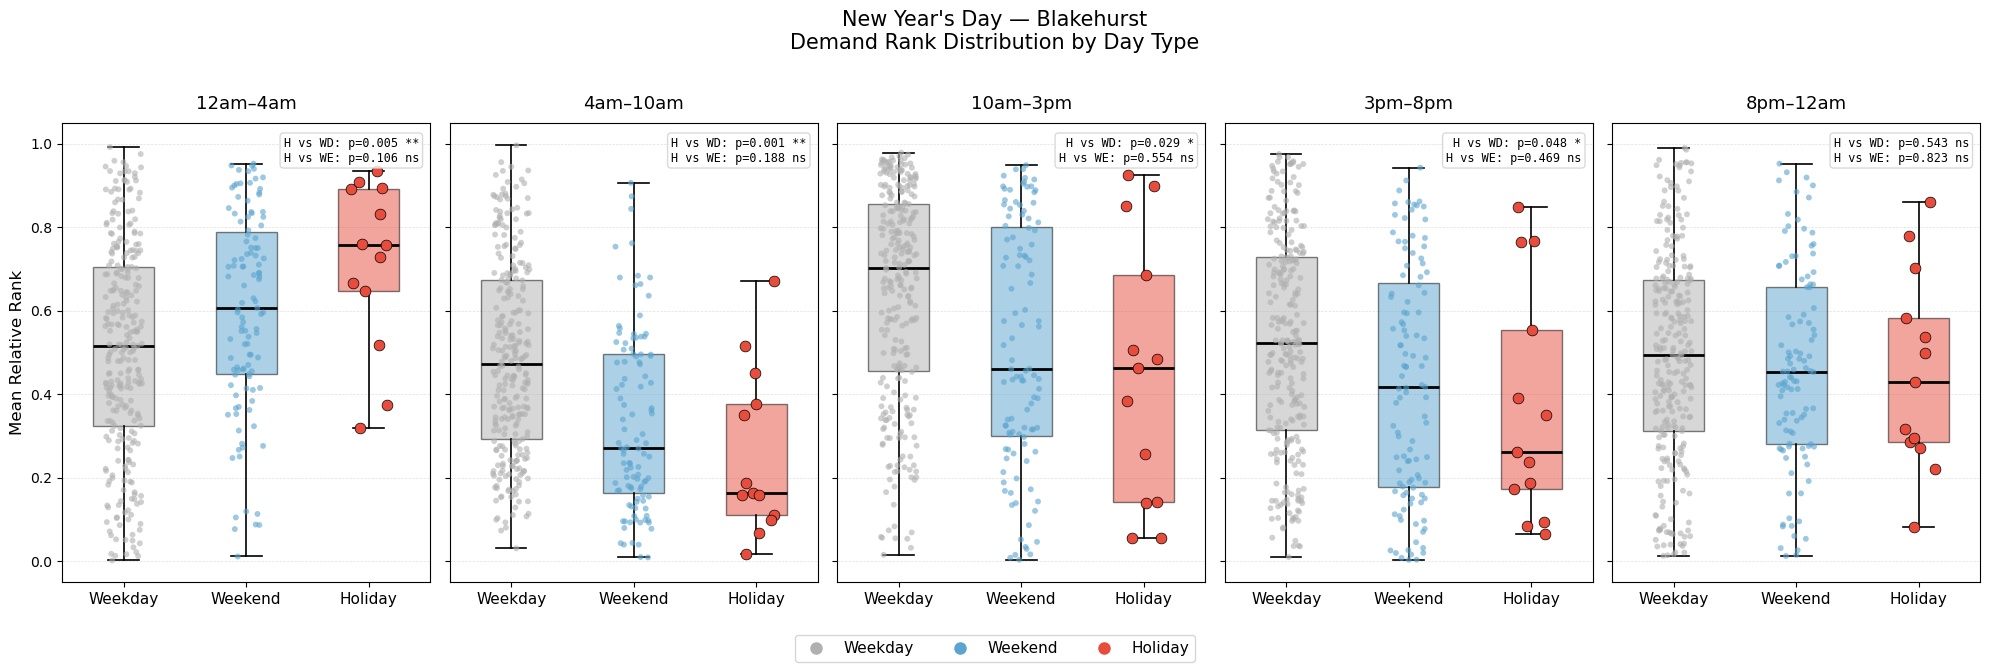

In [47]:
plot_rank_boxstrip_by_daytype(
    demand_rank,
    weather_rank,
    "BLAKE",
    "New Year's Day"
)